## 1. Load BRIDGE model and compute metrics
Please download the dataset from `Figshare`, unzip it, and place it in the expected directory (`BRIDGE/dataset/`). You also need to download the BRIDGE model and place it in the expected directory (`BRIDGE/model/`). Then run the code below to compute the BRIDGE metrics.

In [1]:
%%bash
set -euo pipefail

ROOT_DIR="/home/wangyubo/code/BRIDGE"
cd "${ROOT_DIR}"
DATA_DIR="${ROOT_DIR}/dataset"
LOG="results/logs/validate_all.log"
mkdir -p results/logs

: > "$LOG"

for posfile in "$DATA_DIR"/*_pos.fa; do
  data_file="$(basename "$posfile")"
  data_file="${data_file%_pos.fa}"

  echo "Running validate for: ${data_file}" | tee -a "$LOG"

  python main.py \
    --validate \
    --data_path "$DATA_DIR" \
    --data_file "$data_file" \
    --device_num 0 \
    --Transformer_path ./RBPformer \
    --model_save_path ./results/model \
    2>&1 | tee -a "$LOG"
done


Running validate for: AARS_K562
/home/wangyubo/softwares/anaconda3/envs/BRIDGE/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
Some weights of BertModel were not initialized from the model checkpoint at ./RBPformer and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
[INFO] Encoded 15000 sequences for AARS_K562, shape: (15000, 101, 99)
Valid motif file detected, skipping motif_prior: utils/motif_prior/output/AARS_K562/output/STRME_training_set.tab
AARS_K562 auc: 0.7972 acc: 0.7737 auprc: 0.7224 mcc: 0.4605
Running validat

In [2]:
%%bash
set -euo pipefail

ROOT_DIR="/home/wangyubo/code/BRIDGE"
cd "${ROOT_DIR}"
LOG="results/logs/validate_all.log"
OUT="results/benchmarks/BRIDGE_auc.tsv"
mkdir -p results/benchmarks

echo -e "RBP_Cell\tBRIDGE" > "$OUT"

grep -E '^[A-Za-z0-9]+_[A-Za-z0-9]+ auc:' "$LOG" \
  | awk '{print $1 "\t" $3}' \
  >> "$OUT" || true

echo "Wrote: $OUT"
cat "$OUT"

Wrote: results/benchmarks/BRIDGE_auc.tsv
RBP_Cell	BRIDGE
AARS_K562	0.7972
AUH_HepG2	0.8979
AUH_K562	0.9265


## 2. Downstream analysis of cell type-specific BRIDGE results
### Performance comparison of different four RBP datasets across K562 and HepG2 cell lines
Here we walk through the necessary steps to generate the circos plot for the AUPRC metric.

```{important}
**How to use R code in this notebook?**

We have developed several R scripts to perform downstream analyses, and the essential code for key analyses is provided below. To interactively execute the analysis within this notebook, we utilize the `rpy2` package, which allows running R code directly. Thus, please ensure that `rpy2` is installed (`conda install conda-forge::rpy2`). Alternatively, you may extract these R scripts and execute them externally as standalone R scripts.

The code below initializes `rpy2`. After this setup, you can write and execute R code directly within notebook cells by starting with `%%R`.
```

In [3]:
import logging
import rpy2.rinterface_lib.callbacks
from rpy2.robjects import pandas2ri
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)
pandas2ri.activate()
%load_ext rpy2.ipython

#### Load required packages

To completely finish the following analysis, you need requires specific R packages listed below (`pkgs`), and you can verify and install using the code provided below.

Installing with conda solves most of the dependency package installation problems:
```
conda install -c conda-forge r-ggpubr
conda install r-systemfonts r-ggforce r-funkyheatmap
```

The other packages can be installed just in R:

```
install.packages("cowplot")
install.packages("ggnewscale")
install.packages("ggsci")
```

In [4]:
# %%R
library(ggplot2)       
library(cowplot)       
library(ggpubr)        
library(tidyverse)
library(ggnewscale)
library(ggsci)
library(funkyheatmap)
library(dplyr, warn.conflicts = FALSE)
library(tibble, warn.conflicts = FALSE)
library(RColorBrewer)


function (..., list = character(), package = NULL, lib.loc = NULL, 
    verbose = getOption("verbose"), envir = .GlobalEnv, overwrite = TRUE) 
{
    fileExt <- function(x) {
        db <- grepl("\\.[^.]+\\.(gz|bz2|xz)$", x)
        ans <- sub(".*\\.", "", x)
        ans[db] <- sub(".*\\.([^.]+\\.)(gz|bz2|xz)$", "\\1\\2", 
            x[db])
        ans
    }
    my_read_table <- function(...) {
        lcc <- Sys.getlocale("LC_COLLATE")
        on.exit(Sys.setlocale("LC_COLLATE", lcc))
        Sys.setlocale("LC_COLLATE", "C")
        read.table(...)
    }
    stopifnot(is.character(list))
    names <- c(as.character(substitute(list(...))[-1L]), list)
    if (!is.null(package)) {
        if (!is.character(package)) 
            stop("'package' must be a character vector or NULL")
    }
    paths <- find.package(package, lib.loc, verbose = verbose)
    if (is.null(lib.loc)) 
        paths <- c(path.package(package, TRUE), if (!length(package)) getwd(), 
            paths)
    paths <- unique(normalizePath(paths[file.exists(paths)]))
    paths <- paths[dir.exists(file.path(paths, "data"))]
    dataExts <- tools:::.make_file_exts("data")
    if (length(names) == 0L) {
        db <- matrix(character(), nrow = 0L, ncol = 4L)
        for (path in paths) {
            entries <- NULL
            packageName <- if (file_test("-f", file.path(path, 
                "DESCRIPTION"))) 
                basename(path)
            else "."
            if (file_test("-f", INDEX <- file.path(path, "Meta", 
                "data.rds"))) {
                entries <- readRDS(INDEX)
            }
            else {
                dataDir <- file.path(path, "data")
                entries <- tools::list_files_with_type(dataDir, 
                  "data")
                if (length(entries)) {
                  entries <- unique(tools::file_path_sans_ext(basename(entries)))
                  entries <- cbind(entries, "")
                }
            }
            if (NROW(entries)) {
                if (is.matrix(entries) && ncol(entries) == 2L) 
                  db <- rbind(db, cbind(packageName, dirname(path), 
                    entries))
                else warning(gettextf("data index for package %s is invalid and will be ignored", 
                  sQuote(packageName)), domain = NA, call. = FALSE)
            }
        }
        colnames(db) <- c("Package", "LibPath", "Item", "Title")
        footer <- if (missing(package)) 
            paste0("Use ", sQuote(paste("data(package =", ".packages(all.available = TRUE))")), 
                "\n", "to list the data sets in all *available* packages.")
        else NULL
        y <- list(title = "Data sets", header = NULL, results = db, 
            footer = footer)
        class(y) <- "packageIQR"
        return(y)
    }
    paths <- file.path(paths, "data")
    for (name in names) {
        found <- FALSE
        for (p in paths) {
            tmp_env <- if (overwrite) 
                envir
            else new.env()
            if (file_test("-f", file.path(p, "Rdata.rds"))) {
                rds <- readRDS(file.path(p, "Rdata.rds"))
                if (name %in% names(rds)) {
                  found <- TRUE
                  if (verbose) 
                    message(sprintf("name=%s:\t found in Rdata.rds", 
                      name), domain = NA)
                  thispkg <- sub(".*/([^/]*)/data$", "\\1", p)
                  thispkg <- sub("_.*$", "", thispkg)
                  thispkg <- paste0("package:", thispkg)
                  objs <- rds[[name]]
                  lazyLoad(file.path(p, "Rdata"), envir = tmp_env, 
                    filter = function(x) x %in% objs)
                  break
                }
                else if (verbose) 
                  message(sprintf("name=%s:\t NOT found in names() of Rdata.rds, i.e.,\n\t%s\n", 
                    name, paste(names(rds), collapse = ",")), 
                    domain = NA)
            }
            if (file_test("-f", file.

,Method,exprement,X.1,color_label,value
,<chr>,<chr>,<lgl>,<chr>,<dbl>
0,FTO_K562,AUC,NA,white,0.921
1,FTO_K562,ACC,NA,white,0.870
2,FTO_K562,AUPRC,NA,white,0.877
3,FTO_K562,MCC,NA,black,0.706
4,TIA1_HepG2,AUC,NA,white,0.963
5,TIA1_HepG2,ACC,NA,white,0.884
6,TIA1_HepG2,AUPRC,NA,white,0.933
7,TIA1_HepG2,MCC,NA,black,0.758
8,TBRG4_HepG2,AUC,NA,black,0.749


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message:
“Use of `dt$Method` is discouraged.
ℹ Use `Method` instead.”


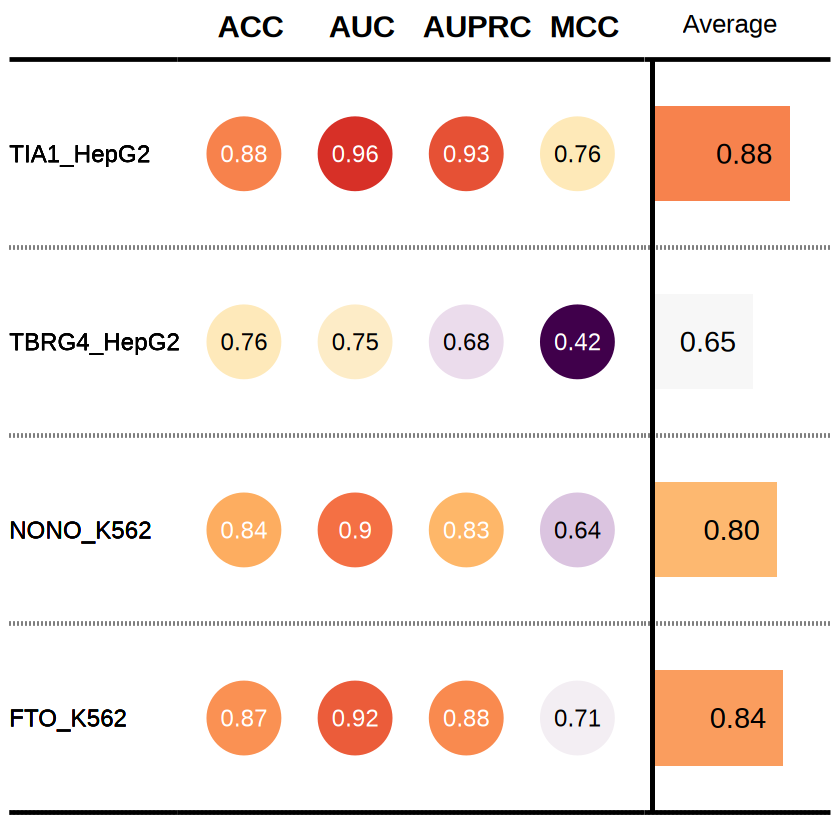

In [5]:
# %%R
paletteContinuous <- function(pal, n = 256, reverse = FALSE) {
  palOut <- colorRampPalette(pal)(n)
  return(palOut)
} 

df <- read.csv("../cell_type_specific/mydata_inR.csv", row.names = "X")
dt <- read.csv("../cell_type_specific/mydata_avg.csv", row.names = "X")
dt$val <- round(dt$val, 3)

wd <- 0.75
mycolor <- c("#dc0000", "#e64b35", "#37b3bf", "#07a28e", "#207687", "#5d6086", "#d18e80", "#84929a", "#c09697", "#8596b5", "#8dbfbe", "#ac847b")
mycolor <- str_to_upper(mycolor)

data

Typeface <- NULL
sample_label <- c(
  'AUC' = 'AUC', 
  'ACC' = 'ACC', 
  'AUPRC' = 'AUPRC', 
  'MCC' = 'MCC',
  "AVG" = "AVG"
)

df

pal <- c(brewer.pal(n = 11, name = "PRGn")[1:6], rev(brewer.pal(n = 11, name = "RdYlBu")[2:5]))
mycolors <- rev(colorRampPalette(pal[6:10])(nrow(dt)))

myplot <- function() {
  p1 <- ggplot() +
    geom_text(aes(x = 0, y = df$Method, label = df$Method, hjust = 0), size = 5) +  
    theme_light() +
    scale_x_continuous(limits = c(0, 1), expand = c(0, 0)) +
    theme(
      panel.grid = element_blank(),
      plot.background = element_blank(),
      axis.title = element_blank(),
      axis.ticks = element_blank(),
      axis.text = element_blank(),
      panel.border = element_blank(),
      plot.margin = margin(),
      axis.ticks.length = unit(0, "mm")
    ) +
    NULL
  
  p2 <- ggplot(df, aes(x=exprement, y=Method, color=value)) +
    geom_point(aes(color=value, size = 10),size=20) +
    # scale_color_distiller(palette = 'PRGn', direction = 1) +
    scale_color_gradientn(colors=pal) +
    new_scale('color')+
    geom_text(aes(label=round(value, 2),color=color_label), size = 5) +
    theme_minimal() +
    labs() +
    theme(
      panel.grid = element_blank(),
      axis.title.x = element_blank(),
      axis.ticks.x = element_blank(),
      axis.title.y = element_blank(),
      axis.text.x = element_text(size = 18, colour = 'black', hjust = 0.4, face = "bold", angle = 0),
      axis.text.y = element_blank(),
      legend.position = 'none',
      legend.title = element_blank(),
      legend.text = element_text(size = 10, colour = 'black',face = "bold"),
      plot.title = element_text(size = 28, colour = 'black',face = "bold", hjust = 0.5, vjust = 0.5),
      plot.margin = margin(),
      axis.ticks.length = unit(0, "mm"),
    ) +
    scale_y_discrete(position = 'left') +
    scale_x_discrete(position = 'top') +
    guides(fill = guide_colorbar(barwidth = unit(0.6, "npc"), barheight = 2), color="none")+
    scale_color_manual(
      values = c("white" = "white", "black" = "black"),
    ) +
    NULL
  
  p3 <- ggplot(dt, aes(x = Method, y = val, fill = val, group = factor(1))) +
    geom_bar(stat = "identity",width=.5) + 
    geom_text(aes(label=sprintf("%0.2f",round(val,2))),hjust=1.3,size=6)+
    coord_flip() +
    xlab(NULL)+
    ylab(NULL)+
    scale_y_continuous(
      limits = c(0, 1.1), 
      breaks = seq(0, 1, by = 0.5),
      labels = c("","Average",""),
      position = "right",
    )+
    theme_bw()+
    theme(panel.grid.major = element_blank(),
          panel.grid.minor = element_blank(),
          panel.border = element_blank(),
          legend.position = 'none',
          axis.text = element_blank(),
          axis.ticks = element_blank(),
          axis.text.x = element_text(size = 15, colour = 'black', hjust = 0.5, face = "plain", angle = 0, margin=margin(l=-10)),
          plot.margin = margin(),
          axis.ticks.length.y = unit(0, "mm"),
    ) +
    geom_segment(aes(x=.5,y=0,xend=length(unique(dt$Method))+0.5,yend=0),linetype="solid",size=1)+
    geom_vline(xintercept = 0,linetype="dotted",size=1)+
    scale_fill_gradientn(
      colors=rev(mycolors),
      name = "Ranking", 
      limits = c(min(dt$val), 1),
      breaks = c(min(dt$val), 1),
      labels = c(length(dt$Method),1)
    )+
    NULL
  for(i in 1:length(unique(df$Method))-1){
    p3 = p3 + geom_vline(xintercept = i+0.5,linetype="dotted",size=1)
    p2 = p2 + geom_hline(yintercept = i+0.5,linetype="dotted",size=1)
    p1 = p1 + geom_hline(yintercept = i+0.5,linetype="dotted",size=1)
  }
  
  p1 = p1 + geom_hline(yintercept = length(unique(df$Method))+0.5,linetype="solid",size=1)
  p2 = p2 + geom_hline(yintercept = length(unique(df$Method))+0.5,linetype="solid",size=1)
  p3 = p3 + geom_vline(xintercept = length(unique(df$Method))+0.5,linetype="solid",size=1)
  
  p1 = p1 + geom_hline(yintercept = 0.5,linetype="solid",size=1)
  p2 = p2 + geom_hline(yintercept = 0.5,linetype="solid",size=1)
  p3 = p3 + geom_vline(xintercept = 0.5,linetype="solid",size=1)
  
  p1+p2+p3+patchwork::plot_layout(byrow=T,widths = c(1.8,5,2))
}
myplot()
